In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_gov = pd.read_csv(
    r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\raw\consumidor_gov\consumidor_gov_processed.csv",
    encoding="utf-8"
)

print(df_gov.shape)
print(df_gov.columns.tolist())
print(df_gov.head())

(125636, 20)
['id_registro', 'fonte', 'data_publicacao', 'titulo', 'texto_original', 'nota', 'usuario', 'categoria', 'status', 'sentimento_real', 'Nome Fantasia', 'Segmento de Mercado', 'Área', 'Assunto', 'Problema', 'Respondida', 'Avaliação Reclamação', 'UF', 'Cidade', 'arquivo_origem']
  id_registro           fonte data_publicacao  \
0      cg_527  consumidor_gov      2025-08-22   
1      cg_965  consumidor_gov      2025-08-28   
2     cg_1390  consumidor_gov      2025-08-31   
3     cg_1420  consumidor_gov      2025-08-31   
4     cg_1665  consumidor_gov      2025-08-31   

                                              titulo  texto_original  nota  \
0  Cobrança por serviço/produto não contratado / ...             NaN   NaN   
1  Dificuldade de contato / acesso a outros canai...             NaN   NaN   
2  Dificuldade de acesso a dados pessoais ou fina...             NaN   NaN   
3              Renegociação / parcelamento de dívida             NaN   NaN   
4  Dificuldade de contato 

In [2]:
print("Total de registros:", len(df_gov))
print(df_gov["fonte"].value_counts())
print(df_gov["data_publicacao"].min(), "até", df_gov["data_publicacao"].max())

Total de registros: 125636
fonte
consumidor_gov    125636
Name: count, dtype: int64
2025-08-22 até 2026-03-31


In [3]:
top_categorias = df_gov["categoria"].value_counts().head(10)
print(top_categorias)

categoria
Cobrança / Contestação          111350
Atendimento / SAC                 5298
Dados Pessoais e Privacidade      3084
Vício de Qualidade                2828
Contrato / Oferta                 2672
Informação                         279
Entrega do Produto                  67
Saúde e Segurança                   58
Name: count, dtype: int64


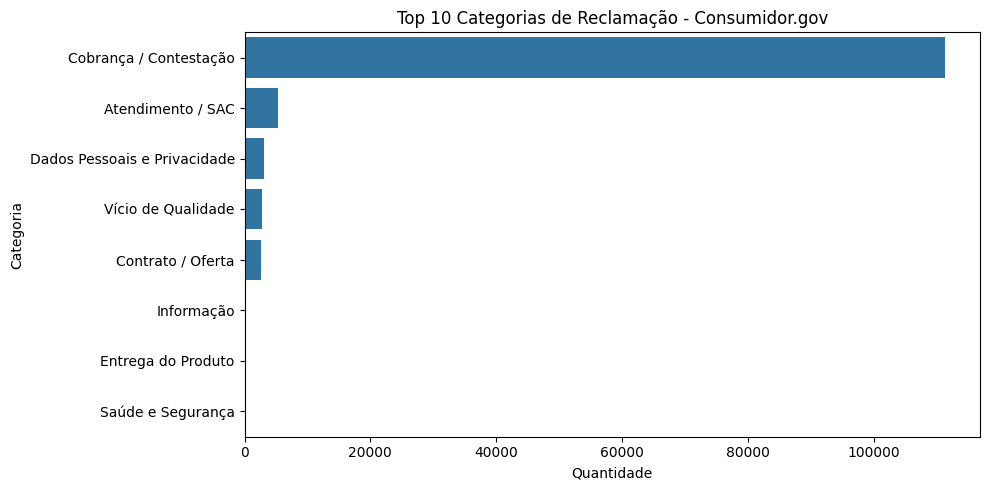

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_categorias.values,
    y=top_categorias.index
)
plt.title("Top 10 Categorias de Reclamação - Consumidor.gov")
plt.xlabel("Quantidade")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

In [5]:
top_problemas = df_gov["Problema"].value_counts().head(10)
print(top_problemas)

Problema
Cálculo de juros, saldo devedor (contestação, solicitação de histórico, dúvidas)        41970
Renegociação / parcelamento de dívida                                                   37204
Cobrança indevida / abusiva para alterar ou cancelar o contrato                         10068
Negativação indevida referente à pagamento já efetuado                                   8918
Cobrança de tarifas, taxas, valores não previstos / não informados                       4228
SAC - Demanda não resolvida / não respondida / respondida após o prazo                   1913
Dificuldade de contato / acesso a outros canais (exceto SAC)                             1329
Dificuldade / atraso na devolução de valores pagos / reembolso / retenção de valores     1293
Bloqueio / Suspensão indevida do serviço                                                 1216
Clonagem, fraude, furto e roubo                                                          1032
Name: count, dtype: int64


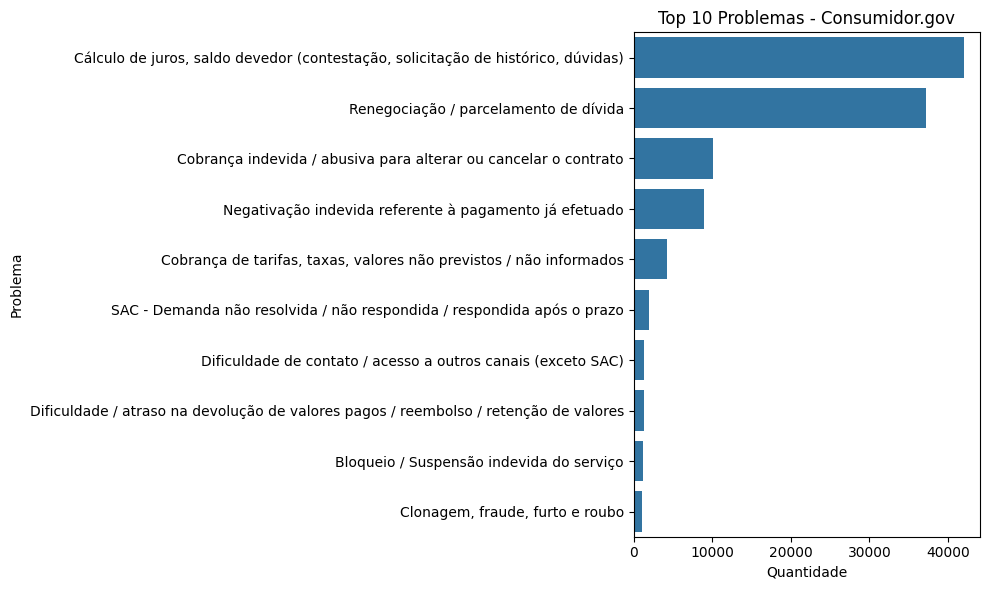

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_problemas.values,
    y=top_problemas.index
)
plt.title("Top 10 Problemas - Consumidor.gov")
plt.xlabel("Quantidade")
plt.ylabel("Problema")
plt.tight_layout()
plt.show()

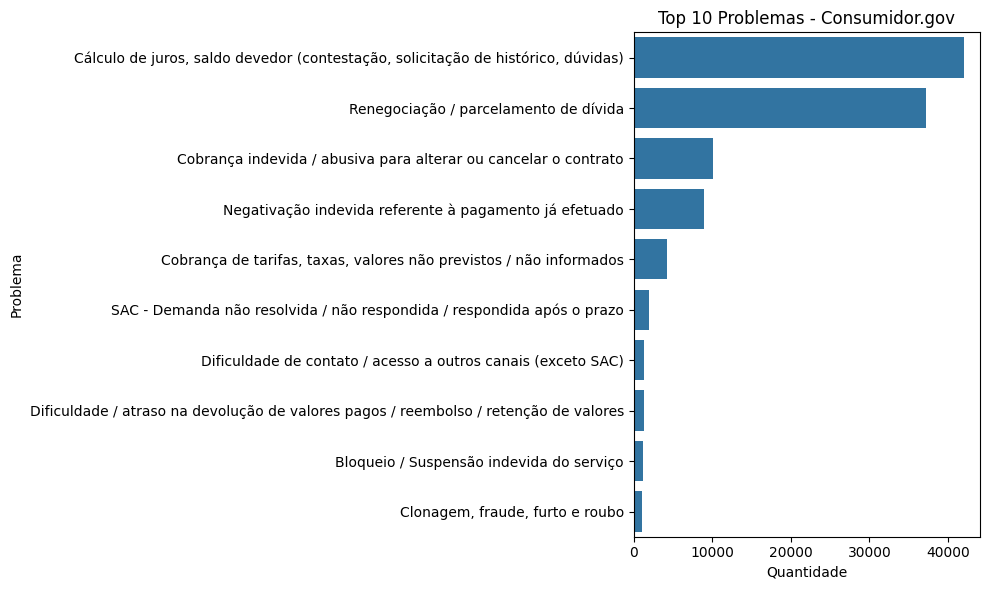

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_problemas.values,
    y=top_problemas.index
)
plt.title("Top 10 Problemas - Consumidor.gov")
plt.xlabel("Quantidade")
plt.ylabel("Problema")
plt.tight_layout()
plt.show()

In [8]:
status_dist = df_gov["status"].value_counts(dropna=False)
status_pct = (df_gov["status"].value_counts(normalize=True, dropna=False) * 100).round(2)

print(status_dist)
print(status_pct)

status
Finalizada não avaliada    95545
Finalizada avaliada        23914
Cancelada                   4498
Encerrada                   1679
Name: count, dtype: int64
status
Finalizada não avaliada    76.05
Finalizada avaliada        19.03
Cancelada                   3.58
Encerrada                   1.34
Name: proportion, dtype: float64


In [9]:
print(df_gov["nota"].describe())
print(df_gov["nota"].value_counts(dropna=False).sort_index())

count    23914.000000
mean         1.753533
std          1.312109
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: nota, dtype: float64
nota
1.0     16589
2.0      2043
3.0      2125
4.0       901
5.0      2256
NaN    101722
Name: count, dtype: int64


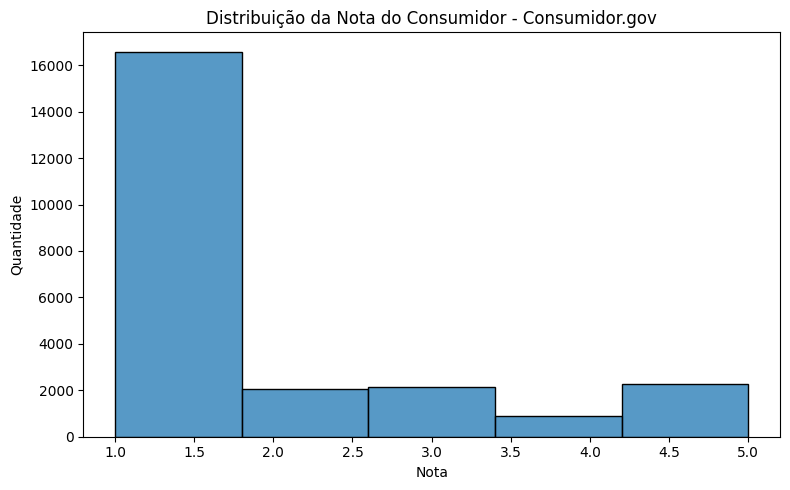

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df_gov["nota"].dropna(), bins=5)
plt.title("Distribuição da Nota do Consumidor - Consumidor.gov")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

In [11]:
df_gov["data_publicacao"] = pd.to_datetime(df_gov["data_publicacao"], errors="coerce")
df_gov["ano_mes"] = df_gov["data_publicacao"].dt.to_period("M").astype(str)

gov_time = df_gov["ano_mes"].value_counts().sort_index()
print(gov_time)

ano_mes
2025-08        5
2025-09    12011
2025-10    18182
2025-11    34250
2025-12    13630
2026-01    24136
2026-02    17251
2026-03     6171
Name: count, dtype: int64


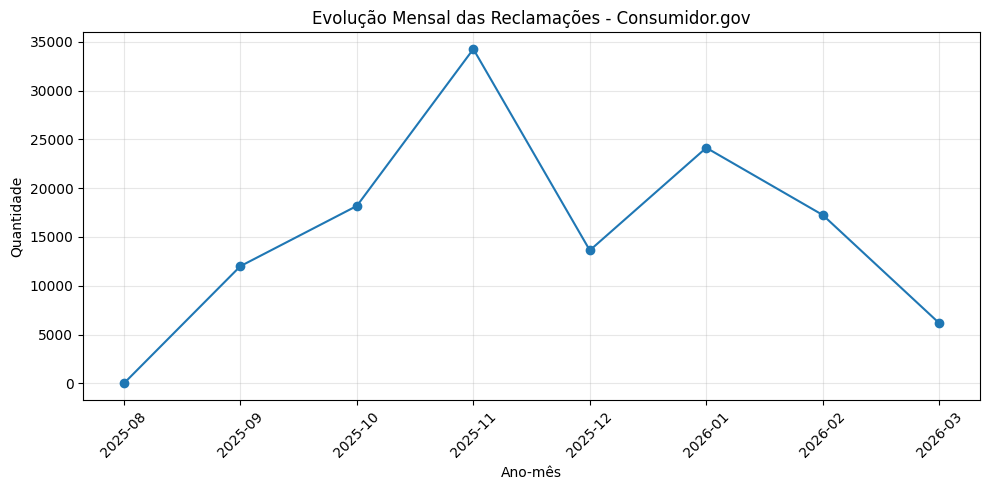

In [12]:
plt.figure(figsize=(10, 5))
gov_time.plot(marker="o")
plt.title("Evolução Mensal das Reclamações - Consumidor.gov")
plt.xlabel("Ano-mês")
plt.ylabel("Quantidade")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
top_ufs = df_gov["UF"].value_counts().head(10)
print(top_ufs)

UF
SP    30879
MG    14912
RJ    10475
PR     7882
BA     7480
RS     6164
GO     5944
SC     5034
CE     4339
PE     3946
Name: count, dtype: int64


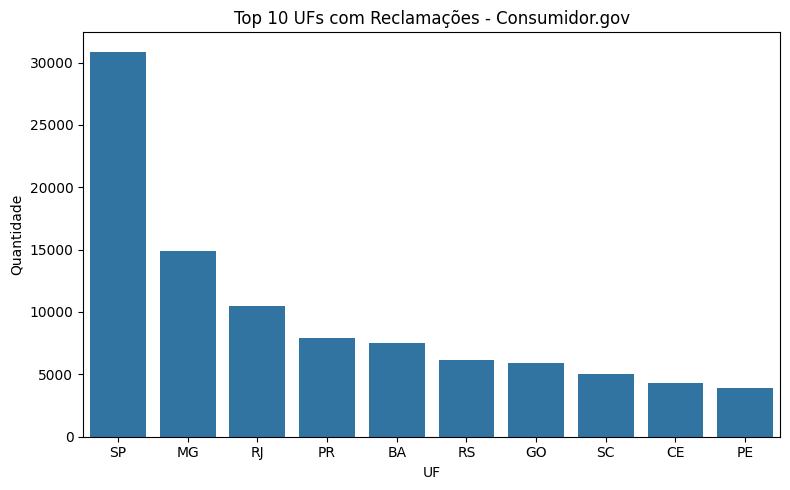

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_ufs.index,
    y=top_ufs.values
)
plt.title("Top 10 UFs com Reclamações - Consumidor.gov")
plt.xlabel("UF")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

In [15]:
top_categorias_df = top_categorias.reset_index()
top_categorias_df.columns = ["categoria", "quantidade"]

In [16]:
status_table = pd.DataFrame({
    "quantidade": status_dist,
    "percentual": status_pct
}).reset_index()
status_table.columns = ["status", "quantidade", "percentual"]

In [17]:
gov_time_df = gov_time.reset_index()
gov_time_df.columns = ["ano_mes", "quantidade"]

In [18]:
top_categorias_df.to_csv(
    r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\gov_top_categorias.csv",
    index=False,
    encoding="utf-8-sig"
)

status_table.to_csv(
    r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\gov_status_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

gov_time_df.to_csv(
    r"C:\Users\Lucca\Documents\New project\nubank-sentiment-analysis\data\processed\gov_time_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos salvos.")

Arquivos salvos.
